# Practico opcional 2: EDA

* Dataset elegido: `FIFA World Cup 2026 - Live Results & Updated Stats  (Squads and Players)`
* La consigna pide realizar: 
    * estadística descriptiva
    * tipos de variables
    * relaciones entre variables
    * incluir al menos 3 gráficos

### 1.Primeras inspecciones al dataset (estadistica descriptiva, tipos de variables)

In [5]:
import pandas 
from pandas.api.types import CategoricalDtype
import numpy 
import matplotlib.pyplot as pyplot
import seaborn 
from scipy import stats 
from scipy.stats import describe

#cargamos el dataset
dataset = pandas.read_csv("./dataset/squads_and_players.csv")
dataset.head()

,player_id,team_id,player_name,position,club_team,market_value_eur,caps,date_of_birth,height_cm,goals
0,1,1,José Raúl Rangel,GK,CD Guadalajara,8933646,15,2000-02-25,190,0
1,2,1,Jorge Eduardo Sanchez,DEF,PAOK Saloniki,24628639,59,1997-12-10,176,3
2,3,1,César Jasib Montes,DEF,FC Lokomotiv Moscow,10912552,69,1997-02-24,191,4
3,4,1,Edson Omar Alvarez,DEF,Fenerbahçe SK,10875943,100,1997-10-24,180,7
4,5,1,Johan Felipe Vasquez,DEF,Genoa CFC,18265363,47,1998-10-22,182,3


In [6]:
#vemos info gral
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1248 entries, 0 to 1247
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   player_id         1248 non-null   int64 
 1   team_id           1248 non-null   int64 
 2   player_name       1248 non-null   object
 3   position          1248 non-null   object
 4   club_team         1248 non-null   object
 5   market_value_eur  1248 non-null   int64 
 6   caps              1248 non-null   int64 
 7   date_of_birth     1248 non-null   object
 8   height_cm         1248 non-null   int64 
 9   goals             1248 non-null   int64 
dtypes: int64(6), object(4)
memory usage: 97.6+ KB


In [7]:
# chequeamos valores faltantes 
print(f"Valores faltantes: {dataset.isnull().sum()}")

Valores faltantes: player_id           0
team_id             0
player_name         0
position            0
club_team           0
market_value_eur    0
caps                0
date_of_birth       0
height_cm           0
goals               0
dtype: int64


#### a) Tipo de variables

In [ ]:
#vemos exclusivamente tipo de variables
dataset.dtypes

player_id            int64
team_id              int64
player_name         object
position            object
club_team           object
market_value_eur     int64
caps                 int64
date_of_birth       object
height_cm            int64
goals                int64
dtype: object

In [ ]:
# corregimos la fecha del cumple de los jugadores
dataset["date_of_birth"] = pandas.to_datetime(dataset["date_of_birth"])
dataset.dtypes

player_id                    int64
team_id                      int64
player_name                 object
position                    object
club_team                   object
market_value_eur             int64
caps                         int64
date_of_birth       datetime64[ns]
height_cm                    int64
goals                        int64
dtype: object

#### b) Estadistica descriptiva

Para esto usamos el metodo describe, el cual devuelve las siguientes filas:
* `count`: Cantidad de valores no nulos.
* `mean` : Promedio o media aritmética de los datos.
* `std` : Desviación estándar (indica qué tan dispersos están los datos respecto a la media).
* `min` : Valor mínimo registrado en la columna.
* `25%` : Primer cuartil (Q1). El 25% de los datos es menor o igual a este valor.
* `50%` : Mediana (Q2). El valor exacto que divide el 50% de los datos.
* `75%` : Tercer cuartil (Q3). El 75% de los datos es menor o igual a este valor.
* `max` : Valor máximo registrado en la columna.

In [ ]:
dataset.drop(columns=['player_id', 'team_id']).describe()  # Media, desvío, mínimo, máximo y cuartiles de las columnas numéricas
# nos interesa todo menos los ids

,market_value_eur,caps,height_cm,goals
count,1.248000e+03,1248.000000,1248.000000,1248.000000
mean,1.549925e+07,34.991186,182.775641,4.523237
std,2.345135e+07,32.231233,6.831644,10.397216
min,2.500000e+04,0.000000,160.000000,0.000000
25%,2.605922e+06,11.000000,178.000000,0.000000
50%,6.571762e+06,26.000000,183.000000,1.000000
75%,1.800000e+07,50.000000,188.000000,4.000000
max,2.000000e+08,229.000000,205.000000,143.000000


### 2. Relacion entre variables

Vamos a elegir a los delanteros y vamos a ver que relacion tienen la cantidad de goles contra:
* Valor de mercado
* Caps (apariciones)
* Altura

In [20]:
delanteros = dataset[dataset["position"]=="FWD"]
delanteros.head()

,player_id,team_id,player_name,position,club_team,market_value_eur,caps,date_of_birth,height_cm,goals
8,9,1,Raúl Alonso Jimenez,FWD,Fulham FC,15211168,127,1991-05-05,188,46
9,10,1,Ernesto Alexis Vega,FWD,Deportivo Toluca FC,17281661,53,1997-11-25,175,7
10,11,1,Santiago Tomás Gimenez,FWD,AC Milan,18000000,47,2001-04-18,180,6
13,14,1,Armando Gonzalez,FWD,CD Guadalajara,8407678,8,2003-04-20,182,1
15,16,1,Julián Andrés Quinones,FWD,Al Qadsiah FC,14000000,23,1997-03-24,177,3


In [ ]:
# Ponemos en una variable las matrices de correlacion
delanteros_correlacion = delanteros[["goals", "market_value_eur","height_cm","caps"]]
delanteros_correlacion.head()

,goals,market_value_eur,height_cm,caps
8,46,15211168,188,127
9,7,17281661,175,53
10,6,18000000,180,47
13,1,8407678,182,8
15,3,14000000,177,23


#### 1. Pearson

Vamos a utilizar Pearson para comparar estas 3 correlaciones.
A priori podemos decir que es razonable pensar que el valor en mercado y la cantidad de apariciones tienen una correlacion con la cantidad de goles de los delanteros. En cambio la altura, quizas no sea algo determinante en la cantidad de goles.

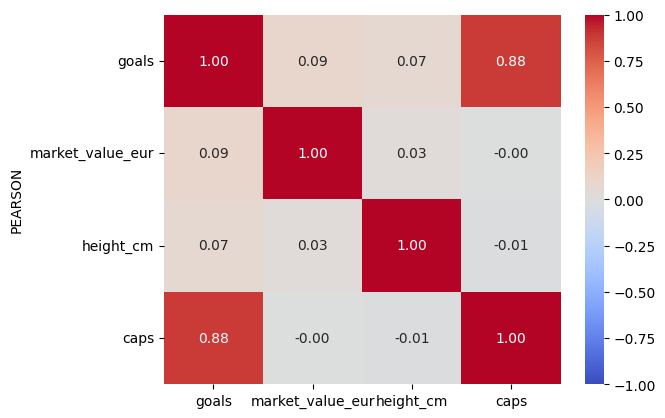

In [27]:
seaborn.heatmap(
    delanteros_correlacion.corr(), 
    annot=True, 
    fmt=".2f", 
    cmap="coolwarm",  
    center=0, 
    vmin=-1, 
    vmax=1)
pyplot.ylabel('PEARSON')
pyplot.show()


Vamos a interpretar este grafico:
* `goals vs caps:` Correlación lineal muy alta. Indica que existe una **relación directa fuerte**: a mayor cantidad de partidos jugados (caps), mayor es la cantidad de goles convertidos por los delanteros.

* `goals vs market_value_eur` Sin relación lineal. Sorprendentemente para Pearson, la cantidad de goles casi no tiene un impacto lineal en el valor de mercado. Esto suele pasar porque los valores de mercado crecen de forma exponencial o tienen **outliers**, donde Spearman probablemente muestre un valor más alto.

* `goals vs height_cm:` Sin relación lineal. La altura del jugador no determina si marca más o menos goles.

#### 2. Spearman

Hagamos lo mismo que con Pearson

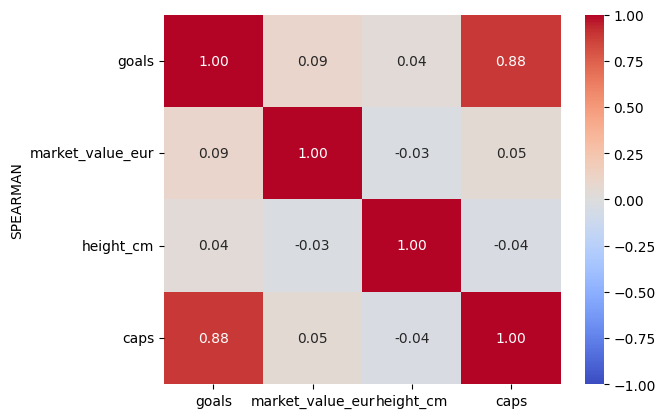

In [28]:
seaborn.heatmap(
    delanteros_correlacion.corr(method='spearman'), 
    annot=True, 
    fmt=".2f", 
    cmap="coolwarm",  
    center=0, 
    vmin=-1, 
    vmax=1)
pyplot.ylabel('SPEARMAN')
pyplot.show()

Llegamos a la conclusion que al evaluar el orden o ranking de los jugadores (relaciones monótonas) en lugar de sus valores numéricos absolutos, los resultados se mantienen prácticamente idénticos:

* `goals vs caps:` Mantiene la misma fuerza que en Pearson. Significa que si ordenamos a los delanteros de menor a mayor cantidad de partidos jugados, el ranking de goles se ordena exactamente en la misma dirección.
* `goals vs market_value_eur:` Es el hallazgo más interesante, en ambos metodos, descartamos que exista una relación monótona oculta. No se trata de que el valor crezca de forma no lineal; sencillamente, **estar más arriba en el ranking de goleadores no garantiza estar más arriba en el ranking de precio**. Quizas factores como la edad, la liga o el potencial pesan mas.
* `goals vs height_cm:` La correlación es nula. La altura no otorga ninguna ventaja en el orden del ranking de goleadores.



#### 3. Kendall

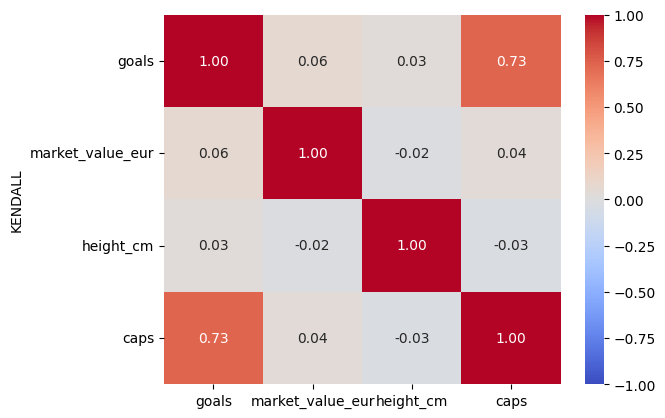

In [29]:
seaborn.heatmap(
    delanteros_correlacion.corr(method='kendall'), 
    annot=True, 
    fmt=".2f", 
    cmap="coolwarm",  
    center=0, 
    vmin=-1, 
    vmax=1)
pyplot.ylabel('KENDALL')
pyplot.show()

Vemos un resultado similar:
* `goals vs caps:`En Pearson y Spearman este valor dio 0.88, y aquí disminuye a 0.73. Esto es completamente normal: Kendall mide el porcentaje neto de pares concordantes (la probabilidad de que al elegir dos delanteros al azar, el que tiene más partidos también tenga más goles). Un valor de 0.73 en Kendall representa una correlación sumamente fuerte y robusta.
* `goals vs market_value_eur:`Sigue estando en un rango prácticamente nulo (0.06). Refuerza que la falta de relación entre goles y valor de mercado es real a todo nivel.
* `goals vs height_cm:`Sin correlación alguna. La altura del delantero no predice la cantidad de goles anotados.

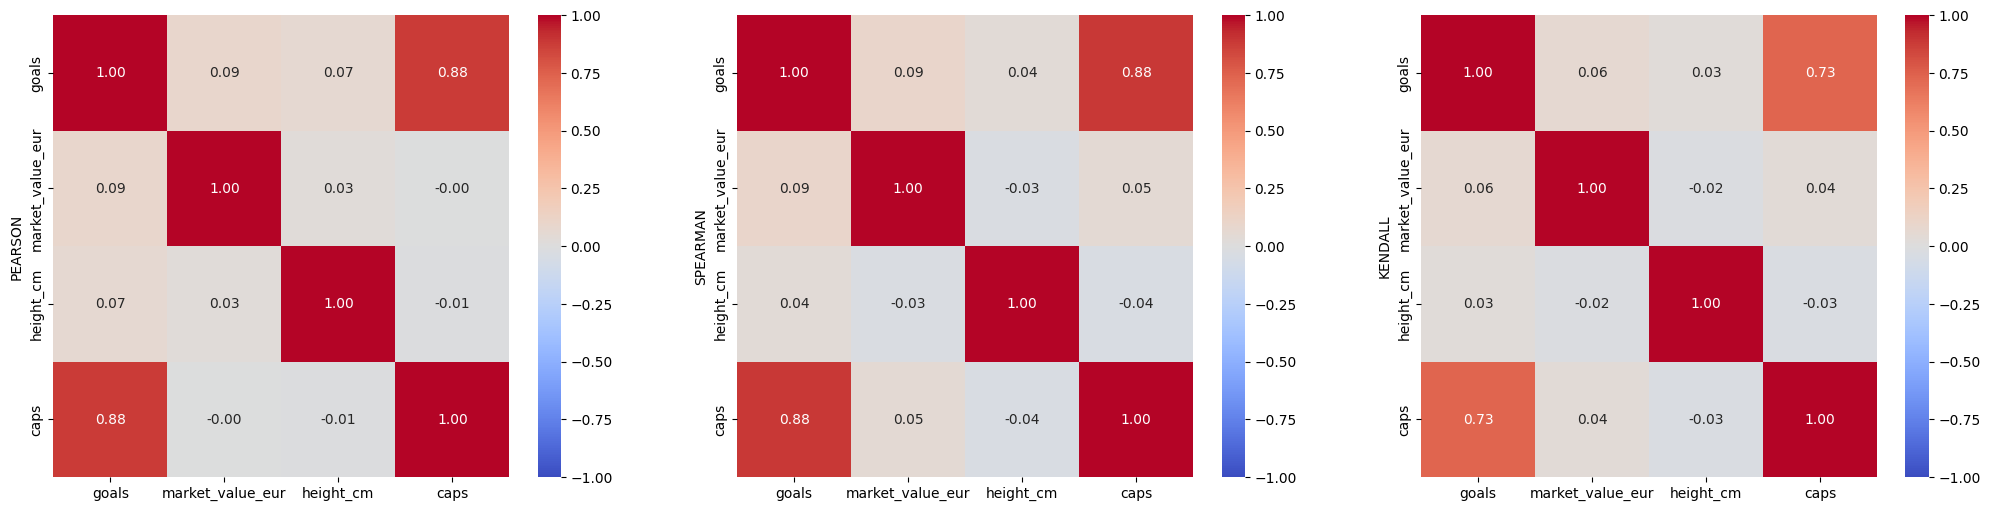

In [32]:
pyplot.figure(figsize=(25,6))

pyplot.subplot(1, 3, 1)
seaborn.heatmap(
    delanteros_correlacion.corr(), 
    annot=True, 
    fmt=".2f", 
    cmap="coolwarm",  
    center=0, 
    vmin=-1, 
    vmax=1)
pyplot.ylabel('PEARSON')

pyplot.subplot(1, 3, 2)
seaborn.heatmap(
    delanteros_correlacion.corr(method='spearman'), 
    annot=True, 
    fmt=".2f", 
    cmap="coolwarm",  
    center=0, 
    vmin=-1, 
    vmax=1)
pyplot.ylabel('SPEARMAN')

pyplot.subplot(1, 3, 3)
seaborn.heatmap(
    delanteros_correlacion.corr(method='kendall'), 
    annot=True, 
    fmt=".2f", 
    cmap="coolwarm",  
    center=0, 
    vmin=-1, 
    vmax=1)
pyplot.ylabel('KENDALL')
pyplot.show()

#### Conclusion

* Hay una única relación determinante: La cantidad de partidos jugados (caps) es la única variable fuertemente asociada a la cantidad de goles anotados (goals)
* La falta de correlación entre goles y valor de mercado demuestra que el precio de un delantero depende de variables externas no presentes en estas 4 columnas (como la edad, contrato restante, asistencias o prestigio de la liga).